# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 12 - przekształcenia geometryczne






### Zadanie 1

1) Utwórz macierz współrzędnych punktów reprezentującą figurę geometryczną, składającą się z co najmniej 4 punktów. Figura powinna mieć "punkt centralny" znajdujący się (w przybliżeniu, nie musi być dokładnie) w punkcie `(0, 0)`.

2) Wyświetl utworzoną figurę na wykresie za pomocą biblioteki `matplotlib`. Upewnij się, że wykres jest czytelny (np. dodaj kolor wypełnienia figury i oznaczenia osi).

> Podpowiedź: możesz użyć funkcji [`plt.fill`](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.fill.html)

Kolejne zadania wykonuj, używając macierzy utworzonej w tym zadaniu, chyba że w treści zadania wskazano inaczej.


In [85]:
import math
import matplotlib
import numpy as np
import matplotlib.animation
import matplotlib.pyplot as plt
from IPython.display import HTML
from mpl_toolkits.mplot3d import Axes3D

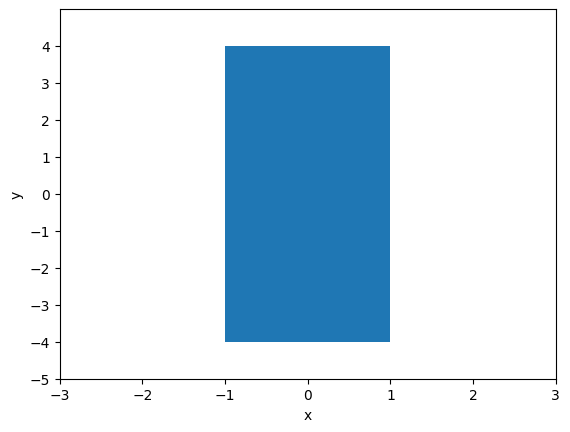

In [24]:
points = [[1,4], [1,-4], [-1,-4], [-1, 4]]
# for point in points:
#     plt.scatter(x=point[0], y=point[1])

xs = [point[0] for point in points]
ys = [point[1] for point in points]

plt.yticks(np.arange(-5,5))
plt.fill(xs,ys)
plt.xlim(-3,3)
plt.ylim(-5,5)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Zadanie 2

Aby wykonać przekształcenie należy pomnożyć _macierz przekształcaną_ przez _macierz przekształcenia_. Poniżej wymienione są przykładowe macierze przekształceń pozwalające wykonać tranformacje:


Obrót o kąt $\theta$:

$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta\\
\text{sin}\theta & \text{cos}\theta
\end{pmatrix}
$$

Rozciągnięcie wzdłuż osi $0x$:

$$
A_k = \begin{pmatrix}
k & 0\\
0 & 1
\end{pmatrix}
$$

Rozciągnięcie wzdłuż osi $0y$:

$$
A_k = \begin{pmatrix}
1 & 0\\
0 & k
\end{pmatrix}
$$

Rozciągnięcie w proporcji $k_x$ wzdłuż osi $0x$ i w proporcji $k_y$ wzdłuż osi $0y$:

$$
A_k = \begin{pmatrix}
k_x & 0\\
0 & k_y
\end{pmatrix}
$$

Pochylenie względem osi $0y$:

$$
A_k = \begin{pmatrix}
1 & k\\
0 & 1
\end{pmatrix}
$$

Pochylenie względem osi $0x$:

$$
A_k = \begin{pmatrix}
1 & 0\\
k & 1
\end{pmatrix}
$$



**Polecenie**

Utwórz trzy animacje dla obrotu, rozciągnięcia i pochylenia (odpowiednio).


Przykład:

<div style="display: flex; flex-direction: row; flex-wrap: wrap; justify-content: center; width:100%;">
<img src="./Figure_2_rot.gif" height="300" width="300" />
<img src="./Figure_2_strech.gif" height="300" width="300" />
<img src="./Figure_2_shear.gif" height="300" width="300" />
</div>


Przykład tworzenia animacji:

```python
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np

fig, ax = plt.subplots(figsize=(8,8))

X = [1, 2, 3, 4]

def animate(i):
    ax.clear()
    ax.set_title(f'{i=}')
    ax.set_xlim(0,5)
    ax.set_ylim(1,10**16)
    ax.set_yscale('log')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.bar(X, [X[0]+i, X[1]*i, X[2]**i, i**X[3]] )

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=36, interval=100, repeat=True) 
ani.save('tmp.gif', writer='imagemagick', fps=100)
```

In [40]:
fig, ax = plt.subplots(figsize=(6,6))

X = [1, 2, 3, 4]

def animate(i):
    ax.clear()
    ax.set_title(f'{i=}')
    ax.set_xlim(0,5)
    ax.set_ylim(1,10**16)
    ax.set_yscale('log')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.bar(X, [X[0]+i, X[1]*i, X[2]**i, i**X[3]] )

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=36, interval=100, repeat=True)
plt.close(fig)
HTML(ani.to_html5_video())

In [74]:
points = np.array([[1,1,-1,-1],
                  [4,-4,-4,4]])

def rotation(deg):
    theta = np.deg2rad(deg)
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    # (2, N) = (2, 2) @ (2, N)
    return R @ points

def stretch(i):
    S = np.array([
        [i, 0],
        [0, 1]
    ])
    return S @ points

def skew(i):
    S = np.array([
        [1, i],
        [0, 1]
    ])
    return S @ points

In [61]:
fig, ax = plt.subplots(figsize=(5,5))

def animate_rotation(i):
    ax.clear()
    deg = i * 10
    pts = rotation(deg)
    ax.fill(pts[0], pts[1])
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_title(f'Rotation: {deg}°')
    ax.grid(True)
    
ani_rot = matplotlib.animation.FuncAnimation(fig, animate_rotation, frames=36, interval=100, repeat=True)
plt.close(fig)
HTML(ani_rot.to_html5_video())

In [72]:
fig, ax = plt.subplots(figsize=(5,5))

def animate_stretch(i):
    ax.clear()
    pts = stretch(i/10)
    ax.fill(pts[0], pts[1])
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_title(f'Stretch')
    ax.grid(True)
    
ani_str = matplotlib.animation.FuncAnimation(fig, animate_stretch, frames=36, interval=100, repeat=True)
plt.close(fig)
HTML(ani_str.to_html5_video())

In [77]:
fig, ax = plt.subplots(figsize=(5,5))

def animate_skew(i):
    ax.clear()
    pts = skew(i/10)
    ax.fill(pts[0], pts[1])
    ax.set_xlim(-20, 20)
    ax.set_ylim(-6, 6)
    ax.set_title(f'Skew')
    ax.grid(True)
    
ani_skw = matplotlib.animation.FuncAnimation(fig, animate_skew, frames=36, interval=100, repeat=True)
plt.close(fig)
HTML(ani_skw.to_html5_video())

### Zadanie 3 (przekształcenia afiniczne)

Przekształcenia afiniczne pozwalają na wykonywanie operacji _translacji_ i łączenia jej z innymi operacjami przekształcenia. 
Aby wykonać przekształcenie afiniczne należy zmienić reprezentację punktu $(x, y) \in R^2$ na $(x, y, 1) \in R^3$. W ten sposób macierz przekształceń osiąga wymiar 3x3. Macierz pozwalająca wykonanie operacji translacji (przesunięcie o wektor $[k_x, k_y]$) wygląda wtedy następująco:



$$
A_k = \begin{pmatrix}
1 & 0 & k_x \\
0 & 1 & k_y \\
0 & 0 & 1
\end{pmatrix}
$$


Pozostałe operacje analogicznie jak wcześniej, np. operacja obrotu:

$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta & 0\\
\text{sin}\theta & \text{cos}\theta & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

**Polecenie**

Wykonaj animację, gdzie operacja translacji oraz obrotu są wykonywane za pomocą jednej operacji macierzowej.

> Podpowiedź: należy "połączyć" macierze przekształceń w jedną.


Przykład:

<img src="./Figure_3.gif" height="300" width="300" />

In [84]:
points_affine = np.vstack([points, np.ones(points.shape[1])])

def affine(i):    
    theta = np.deg2rad(i * 10)
    
    A_translation = np.array([
        [1, 0, i/5],
        [0, 1, i/5],
        [0, 0, 1]
    ])
    A_rotation = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 1],
        [0, 0, 1]
    ])
    
    A = A_translation @ A_rotation
    
    return A @ points_affine

fig, ax = plt.subplots(figsize=(5,5))

def animate_affine(i):
    ax.clear()
    pts = affine(i)
    ax.fill(pts[0], pts[1])
    ax.set_xlim(-20, 40)
    ax.set_ylim(-6, 12)
    ax.set_title(f'animate_affine')
    ax.grid(True)
    
ani_aff = matplotlib.animation.FuncAnimation(fig, animate_affine, frames=36, interval=100, repeat=True)
plt.close(fig)
HTML(ani_aff.to_html5_video())

### Zadanie 4 (przekształcenia macierzowe w 3D)

1) Utwórz prostą figurę geometryczną złożoną z 8 punktów w przestrzeni 3D (podobnie jak w pierwszym zadaniu).

Przykład:

```python
fig = plt.figure()
ax = Axes3D(fig)

m = np.array([
    [-1, -1, -1],
    [-1, 2, -1],
    [2, -1, -1],
    [2, 2, -1],
    [-1, -1, 2],
    [-1, 2, 2],
    [2, -1, 2],
    [2, 2, 2]
])

ax.scatter(m[:, 0], m[:, 1], m[:, 2])
```

2) Utwórz animację obrotu figury względem osi $0z$.

> Aby wykonać taki obrót należy użyć poniższej macierzy przekształceń:
$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta & 0\\
\text{sin}\theta & \text{cos}\theta & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

**Przykład**


<img src="./Figure_4.gif" height="300" width="300" />

In [116]:
m = np.array([
    [-1, -1, -1],
    [-1, 2, -1],
    [2, -1, -1],
    [2, 2, -1],
    [-1, -1, 2],
    [-1, 2, 2],
    [2, -1, 2],
    [2, 2, 2]
])

print(m.shape)

(8, 3)


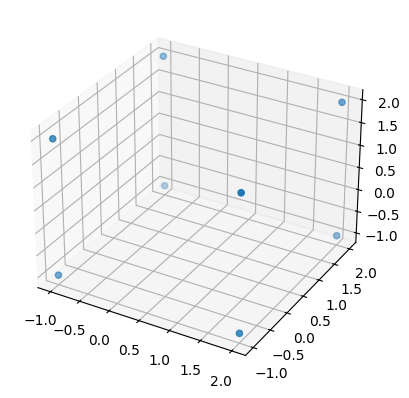

In [117]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(m[:, 0], m[:, 1], m[:, 2])
plt.show()

In [121]:
def rotate_3d(i):
    theta = np.deg2rad(i * 10)
    A = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    #(8,3) = (8,3) @ (3,3)
    return A @ m.T
    
def animate_cube(i):
    ax.clear()
    pts = rotate_3d(i)
    ax.scatter(pts[0], pts[1], pts[2], color='blue', s=60)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-3, 3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Obrót wokół OZ, θ={i * 10}°')
    ax.grid(True)
    
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ani_cube = matplotlib.animation.FuncAnimation(fig, animate_cube, frames=36, interval=100, repeat=True)
plt.close(fig)
HTML(ani_cube.to_html5_video())

### Zadanie 5

Połącz punkty (jeżeli nie zrobiłeś tego wcześniej) figury z poprzedniego zadania.

<img src="./Figure_5.gif" height="300" width="300" />

In [120]:
def get_cube(v = None, *, limits=None):
    """get the vertices, edges, and faces of a cuboid defined by its limits

    limits = np.array([[x_min, x_max],
                       [y_min, y_max],
                       [z_min, z_max]])
    """
    # v = np.array([[0, 0, 0], [0, 0, 1],
    #             [0, 1, 0], [0, 1, 1],
    #             [1, 0, 0], [1, 0, 1],
    #             [1, 1, 0], [1, 1, 1]], dtype=int)
    
    if limits is not None:
        v = limits[np.arange(3)[np.newaxis, :].repeat(8, axis=0), v]

    e = np.array([[0, 1], [0, 2], [0, 4],
                  [1, 3], [1, 5],
                  [2, 3], [2, 6],
                  [3, 7],
                  [4, 5], [4, 6],
                  [5, 7],
                  [6, 7]], dtype=int)

    f = np.array([[0, 2, 3, 1],
                  [0, 4, 5, 1],
                  [0, 4, 6, 2],
                  [1, 5, 7, 3],
                  [2, 6, 7, 3],
                  [4, 6, 7, 5]], dtype=int)

    return v, e, f

In [127]:
def rotate_3d(i, m):
    theta = np.deg2rad(i * 10)
    A = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    #(8,3) = (8,3) @ (3,3)
    return m @ A
    
def animate_cube(i):
    ax.clear()
    pts = rotate_3d(i, v)
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], color='blue', s=60)
    for p, q in e:
        ax.plot(*pts[[p, q], :].T, color='r', ls='-')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-3, 3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Obrót wokół OZ, θ={i * 10}°')
    ax.grid(True)
    
v, e, f = get_cube(m)
    
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ani_cube = matplotlib.animation.FuncAnimation(fig, animate_cube, frames=36, interval=100, repeat=True)
plt.close(fig)
HTML(ani_cube.to_html5_video())